# Sedimentation rate

Sedimentation rates are taken from modle output presented in https://doi.org/10.1007/s00367-020-00669-1 .

In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd

In [2]:
ds = nc.Dataset('inputs\prediction.nc')
ds_sd = nc.Dataset('inputs\prediction_sdev.nc')

lat_grid = ds.variables['lat'][:]
lon_grid = ds.variables['lon'][:]
z   = np.array(ds.variables['z'][:],   dtype=np.float64)  # log10(cm/yr)
sd  = np.array(ds_sd.variables['z'][:], dtype=np.float64)

ds.close()
ds_sd.close()

# Convert to linear space (NaN stays NaN)
rate_cmyr = 10 ** z
sdev_cmyr = 10 ** sd

def get_rate(lat_query, lon_query, search_radius=10):
    """
    Get sedimentation rate at (lat_query, lon_query).
    If the nearest cell is NaN (land/gap), searches within
    a growing window for the nearest valid offshore cell.
    """
    lat_idx = np.argmin(np.abs(lat_grid - lat_query))
    lon_idx = np.argmin(np.abs(lon_grid - lon_query))

    rate = rate_cmyr[lat_idx, lon_idx]
    sdev = sdev_cmyr[lat_idx, lon_idx]

    found_idx = (lat_idx, lon_idx)
    fallback = False

    if np.isnan(rate):
        fallback = True
        # Search expanding neighborhood for nearest valid cell
        found = False
        for r in range(1, search_radius + 1):
            la_slice = slice(max(0, lat_idx - r), min(rate_cmyr.shape[0], lat_idx + r + 1))
            lo_slice = slice(max(0, lon_idx - r), min(rate_cmyr.shape[1], lon_idx + r + 1))
            patch = rate_cmyr[la_slice, lo_slice]
            valid = np.argwhere(~np.isnan(patch))
            if len(valid) > 0:
                # Pick the one closest to center
                center = np.array([r, r])
                dists = np.linalg.norm(valid - center, axis=1)
                best = valid[np.argmin(dists)]
                found_idx = (la_slice.start + best[0], lo_slice.start + best[1])
                rate = rate_cmyr[found_idx]
                sdev = sdev_cmyr[found_idx]
                found = True
                break
        if not found:
            print(f"No valid data within search radius for ({lat_query}, {lon_query})")
            return None, None

    status = f"(nearest valid cell — original point on land/gap)" if fallback else ""
    print(f"Query        : {lat_query}°N, {lon_query}°E")
    print(f"Nearest cell : {float(lat_grid[found_idx[0]]):.4f}°N, {float(lon_grid[found_idx[1]]):.4f}°E  {status}")
    print(f"Rate         : {rate:.4f} cm/yr")
    print(f"Std dev      : ±{sdev:.4f} cm/yr")
    print()
    return rate, sdev


# --- Single point ---
get_rate(43.5, 3.5)

# --- Batch ---
coords = [
    (43.5,  3.5),
    (36.0, -5.5),
    (51.5,  2.0),
]

for la, lo in coords:
    get_rate(la, lo)

Query        : 43.5°N, 3.5°E
Nearest cell : 43.3750°N, 3.5417°E  (nearest valid cell — original point on land/gap)
Rate         : 0.1951 cm/yr
Std dev      : ±1.7468 cm/yr

Query        : 43.5°N, 3.5°E
Nearest cell : 43.3750°N, 3.5417°E  (nearest valid cell — original point on land/gap)
Rate         : 0.1951 cm/yr
Std dev      : ±1.7468 cm/yr

Query        : 36.0°N, -5.5°E
Nearest cell : 36.0417°N, -5.4583°E  
Rate         : 0.2573 cm/yr
Std dev      : ±3.3840 cm/yr

Query        : 51.5°N, 2.0°E
Nearest cell : 51.5417°N, 2.0417°E  
Rate         : 0.0750 cm/yr
Std dev      : ±1.4566 cm/yr



In [3]:
get_rate(-29.889722, 31.007500)

Query        : -29.889722°N, 31.0075°E
Nearest cell : -29.8750°N, 31.0417°E  
Rate         : 0.0165 cm/yr
Std dev      : ±4.4361 cm/yr



(np.float64(0.016479407577531843), np.float64(4.436126164409045))

## Dataframe

In [5]:
coordinates = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
coordinates

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [6]:
lat = coordinates['Lat_center'].to_list()
lon = coordinates['Lon_center'].to_list()

In [7]:
def get_rate(lat_query, lon_query,output_storage, search_radius=10, ):
    """
    Get sedimentation rate at (lat_query, lon_query).
    If the nearest cell is NaN (land/gap), searches within
    a growing window for the nearest valid offshore cell.
    """
    lat_idx = np.argmin(np.abs(lat_grid - lat_query))
    lon_idx = np.argmin(np.abs(lon_grid - lon_query))

    rate = rate_cmyr[lat_idx, lon_idx]
    sdev = sdev_cmyr[lat_idx, lon_idx]

    found_idx = (lat_idx, lon_idx)
    fallback = False

    

    if np.isnan(rate):
        fallback = True
        # Search expanding neighborhood for nearest valid cell
        found = False
        for r in range(1, search_radius + 1):
            la_slice = slice(max(0, lat_idx - r), min(rate_cmyr.shape[0], lat_idx + r + 1))
            lo_slice = slice(max(0, lon_idx - r), min(rate_cmyr.shape[1], lon_idx + r + 1))
            patch = rate_cmyr[la_slice, lo_slice]
            valid = np.argwhere(~np.isnan(patch))
            if len(valid) > 0:
                # Pick the one closest to center
                center = np.array([r, r])
                dists = np.linalg.norm(valid - center, axis=1)
                best = valid[np.argmin(dists)]
                found_idx = (la_slice.start + best[0], lo_slice.start + best[1])
                rate = rate_cmyr[found_idx]
                sdev = sdev_cmyr[found_idx]
                found = True
                break
        if not found:
            print(f"No valid data within search radius for ({lat_query}, {lon_query})")
            return None, None

    status = f"(nearest valid cell — original point on land/gap)" if fallback else ""
    print(f"Query        : {lat_query}°N, {lon_query}°E")
    print(f"Nearest cell : {float(lat_grid[found_idx[0]]):.4f}°N, {float(lon_grid[found_idx[1]]):.4f}°E  {status}")
    print(f"Rate         : {rate:.4f} cm/yr")
    print(f"Std dev      : ±{sdev:.4f} cm/yr")
    print()

    output_storage.append((rate, sdev))

    return rate, sdev


In [8]:
out=[]
for i in range(len(lat)):
    get_rate(lat[i], lon[i], output_storage=out)

Query        : -74.5°N, 163.5°E
Nearest cell : -74.8750°N, 163.7917°E  (nearest valid cell — original point on land/gap)
Rate         : 0.1580 cm/yr
Std dev      : ±2.0561 cm/yr

Query        : -74.5°N, 164.5°E
Nearest cell : -74.6250°N, 164.5417°E  (nearest valid cell — original point on land/gap)
Rate         : 0.1242 cm/yr
Std dev      : ±1.5163 cm/yr

Query        : -42.5°N, 147.5°E
Nearest cell : -42.7917°N, 147.5417°E  (nearest valid cell — original point on land/gap)
Rate         : 0.1008 cm/yr
Std dev      : ±3.7455 cm/yr

Query        : -38.5°N, 144.5°E
Nearest cell : -38.4583°N, 144.5417°E  
Rate         : 0.2747 cm/yr
Std dev      : ±2.9984 cm/yr

Query        : -35.5°N, 138.5°E
Nearest cell : -35.6250°N, 138.6250°E  (nearest valid cell — original point on land/gap)
Rate         : 0.2669 cm/yr
Std dev      : ±2.1202 cm/yr

Query        : -34.5°N, 150.5°E
Nearest cell : -34.5417°N, 150.8750°E  (nearest valid cell — original point on land/gap)
Rate         : 0.0154 cm/yr
Std d

In [9]:
out
output = pd.DataFrame(out, columns=['Rate (cm/yr)', 'Std Dev (cm/yr)'])

In [10]:
coordinates['Sedimentation rate cm/yr'] = output['Rate (cm/yr)']
coordinates

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Sedimentation rate cm/yr
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,0.158011
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,0.124240
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,0.100824
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,0.274720
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,0.266869
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,0.037953
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,0.037904
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,0.019831
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,0.023832


In [11]:
coordinates.to_csv('outputs\Sedimentation rates dataset.csv', index=False)

# Stat

In [12]:
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import matplotlib.pyplot as plt

In [13]:
# Normalize data for statistidata_pointscs
data_points_copy = coordinates.copy()
data_points_copy['Sedimentation rate cm/yr'] = data_points_copy['Sedimentation rate cm/yr'].apply(pd.to_numeric, errors='coerce').fillna(0)

cols_to_normalize = ['MEAN MP stock (g/m2) in 2021',
                     'Sedimentation rate cm/yr']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]


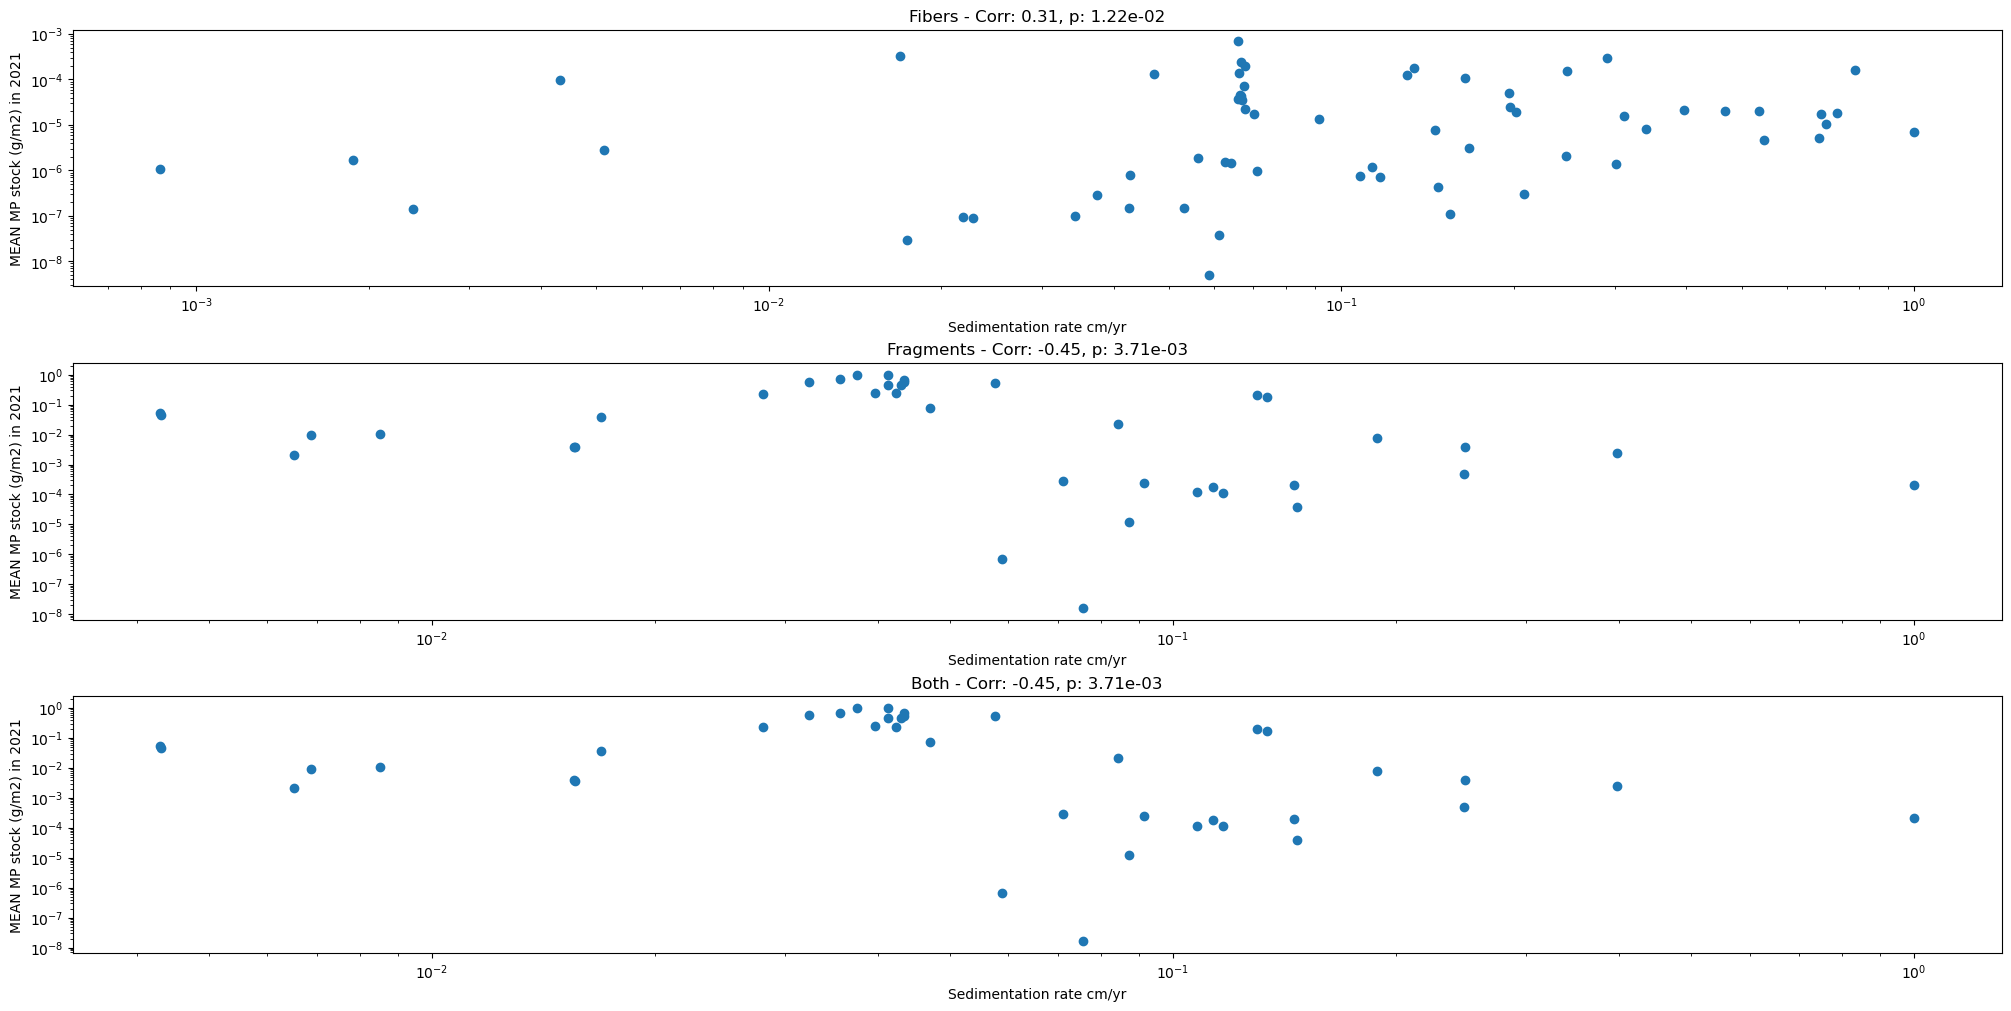

In [14]:
fig, axs = plt.subplots(3, 1, layout="constrained", figsize=(20, 10))
ax1, ax2, ax3 = axs.flatten()

cmap = plt.colormaps['plasma']

spearman_results = []

# Fibers
x = data_points_fib['Sedimentation rate cm/yr']
y = data_points_fib['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Sedimentation rate cm/yr Fibers stock', spearman_stock[0], spearman_stock[1]])

ax1.scatter(data_points_fib['Sedimentation rate cm/yr'], data_points_fib['MEAN MP stock (g/m2) in 2021'])
ax1.set_title(f"Fibers - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Fragments
x = data_points_frg['Sedimentation rate cm/yr']
y = data_points_frg['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Sedimentation rate cm/yr Fragments stock', spearman_stock[0], spearman_stock[1]])

ax2.scatter(data_points_frg['Sedimentation rate cm/yr'], data_points_frg['MEAN MP stock (g/m2) in 2021'])
ax2.set_title(f"Fragments - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Both
x = data_points_frg['Sedimentation rate cm/yr']
y = data_points_frg['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Sedimentation rate cm/yr Both together stock', spearman_stock[0], spearman_stock[1]])

ax3.scatter(data_points_frg['Sedimentation rate cm/yr'], data_points_frg['MEAN MP stock (g/m2) in 2021'])
ax3.set_title(f"Both - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Labels

for ax in axs.flatten():
    ax.set_xlabel('Sedimentation rate cm/yr')
    ax.set_ylabel('MEAN MP stock (g/m2) in 2021')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.show()

In [15]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats

,Parameter,Spearman Correlation,Spearman p-value
0,Sedimentation rate cm/yr Fibers stock,0.309178,0.012209
1,Sedimentation rate cm/yr Fragments stock,-0.453846,0.003708
2,Sedimentation rate cm/yr Both together stock,-0.453846,0.003708
